# Lab 1 — Decision Tree and Random Forest (Complete)

This notebook contains **Part A**, the original lab code (with small bug fixes, each marked **FIX**), and **Part B**, the Mushroom classification task:

- B2. Exploratory Data Analysis (EDA)
- B3. Random Forest accuracy for `n_estimators` = 1, 50, 100, 150, 200, 250
- B4. Random Forest vs Decision Tree comparison

# PART A — Original Lab Code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from graphviz import Digraph

## A1. Load the Iris dataset

In [2]:
iris = load_iris()
# Convert the data to a pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Add the target column
df['species'] = iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [3]:
print(df.shape)
print(df.describe())

(150, 5)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


Analyze the dataset

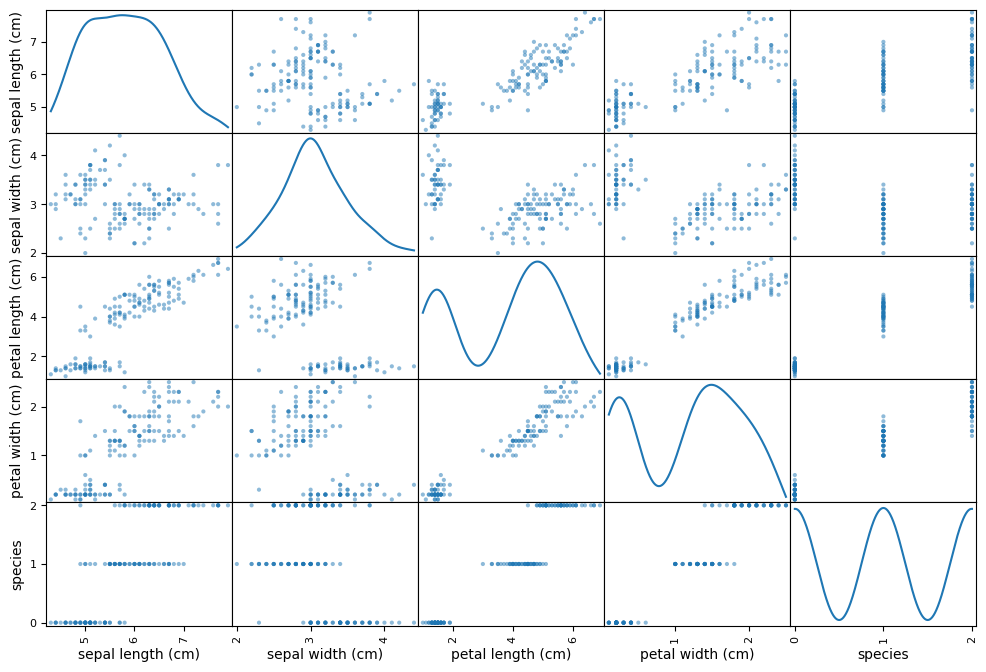

In [4]:
# Pairwise scatter plot of the features
pd.plotting.scatter_matrix(df, figsize=(12, 8), diagonal='kde')
plt.show()

## A2. Decision Tree using NumPy (from scratch)

**FIX:** `best_split` returns `None` when no split improves information gain (identical feature rows with different labels), which crashed `build_tree`. A majority-vote leaf is now returned in that case.

**FIX:** The trained model was stored in a variable called `tree`, which overwrote `from sklearn import tree` and broke the Random Forest plot later. It is now called `custom_tree`.

In [5]:
X = iris.data
y = iris.target
# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
class DecisionTree:
    def __init__(self, max_depth=None, feature_names=None):
        self.max_depth = max_depth
        self.tree = None
        self.feature_names = feature_names

    def entropy(self, y):
        """Entropy H(y) = -sum p_i * log2(p_i)."""
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities))

    def information_gain(self, y, y1, y2):
        """IG = H(parent) - weighted average of H(children)."""
        p = len(y1) / len(y)
        return self.entropy(y) - p * self.entropy(y1) - (1 - p) * self.entropy(y2)

    def best_split(self, X, y):
        """Try every unique value of every feature as a threshold; keep the highest IG."""
        best_gain = 0
        best_feature_index = None
        best_threshold = None
        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                y1 = y[X[:, feature_index] <= threshold]
                y2 = y[X[:, feature_index] > threshold]
                gain = self.information_gain(y, y1, y2)
                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold
        return best_feature_index, best_threshold

    def build_tree(self, X, y, depth=0):
        """Build the tree recursively."""
        if len(np.unique(y)) == 1:                       # pure node -> leaf
            return y[0]
        if self.max_depth is not None and depth >= self.max_depth:
            return np.argmax(np.bincount(y))             # depth limit -> majority leaf
        feature_index, threshold = self.best_split(X, y)
        if feature_index is None:                        # FIX: no useful split -> majority leaf
            return np.argmax(np.bincount(y))
        left_indices = X[:, feature_index] <= threshold
        right_indices = X[:, feature_index] > threshold
        left_tree = self.build_tree(X[left_indices], y[left_indices], depth + 1)
        right_tree = self.build_tree(X[right_indices], y[right_indices], depth + 1)

        feature_name = self.feature_names[feature_index] if self.feature_names else feature_index
        return {
            'feature_name': feature_name,
            'feature_index': feature_index,
            'threshold': threshold,
            'left': left_tree,
            'right': right_tree,
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict(self, X):
        if len(X.shape) == 1:  # single sample
            X = X.reshape(1, -1)
        return np.array([self._predict(self.tree, x) for x in X])

    def _predict(self, tree, x):
        if isinstance(tree, dict):
            if x[tree['feature_index']] <= tree['threshold']:
                return self._predict(tree['left'], x)
            else:
                return self._predict(tree['right'], x)
        else:
            return tree

    def visualize_tree(self, tree=None, dot=None, parent=None, edge_label=None):
        """Visualize the tree with graphviz."""
        if dot is None:
            dot = Digraph()
            dot.node(name='root', label=str(tree['feature_name']) + ' <= ' + str(round(tree['threshold'], 2)))
            self.visualize_tree(tree['left'], dot, 'root', 'True')
            self.visualize_tree(tree['right'], dot, 'root', 'False')
            return dot

        if isinstance(tree, dict):
            node_id = str(id(tree))
            node_label = str(tree['feature_name']) + ' <= ' + str(round(tree['threshold'], 2))
            dot.node(name=node_id, label=node_label)
            if parent is not None:
                dot.edge(parent, node_id, label=edge_label)
            self.visualize_tree(tree['left'], dot, node_id, 'True')
            self.visualize_tree(tree['right'], dot, node_id, 'False')
        else:
            node_id = str(id(tree)) + '_' + str(parent) + '_' + str(edge_label)
            dot.node(name=node_id, label=str(tree), shape='box')  # leaves as boxes
            if parent is not None:
                dot.edge(parent, node_id, label=edge_label)

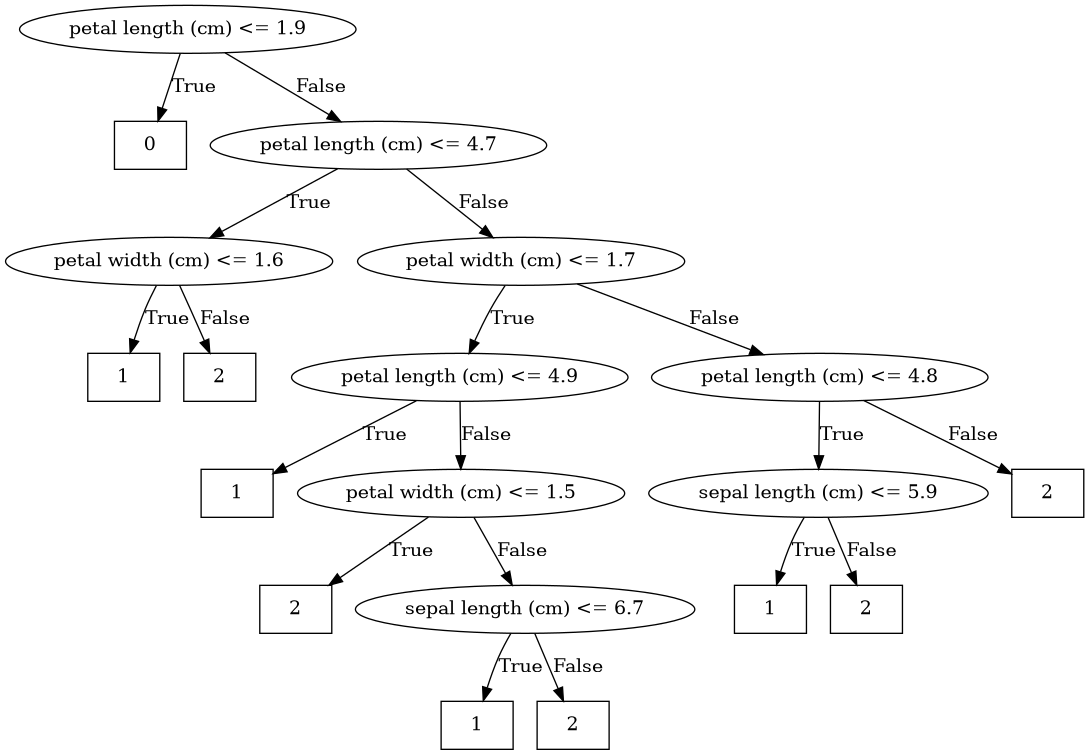

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


In [7]:
feature_names = iris.feature_names

# Train the from-scratch tree (FIX: renamed from `tree` to `custom_tree`)
custom_tree = DecisionTree(max_depth=6, feature_names=feature_names)
custom_tree.fit(X_train, y_train)

# Visualize the tree
dot = custom_tree.visualize_tree(custom_tree.tree)
dot.render('decision_tree', format='png')
from IPython.display import Image, display
display(Image('decision_tree.png'))

# Evaluate
y_pred = custom_tree.predict(X_test)
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred, average='macro'):.4f}")

## A3. Decision Tree using scikit-learn

**FIX (the "fix the error" cell):** the original code used `df.drop('target', axis=1)`, but the Iris DataFrame's label column is called `'species'`, so it raised a `KeyError`.

In [8]:
# Define the features and the target  (FIX: 'target' -> 'species')
X = df.drop('species', axis=1)
y = df['species']
# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train and test

In [9]:
# Decision tree with ENTROPY criterion and max depth 3  (FIX: comment said 'gini')
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

Show the results

Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-score:  1.00


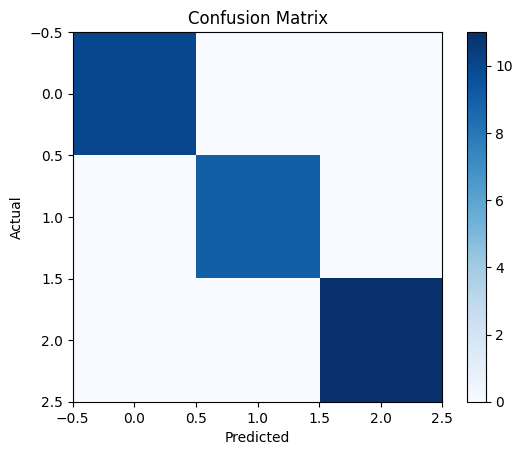

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [10]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Accuracy:  {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-score:  {f1:.2f}")

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.colorbar()
plt.show()
print(classification_report(y_test, y_pred))

Plot the tree

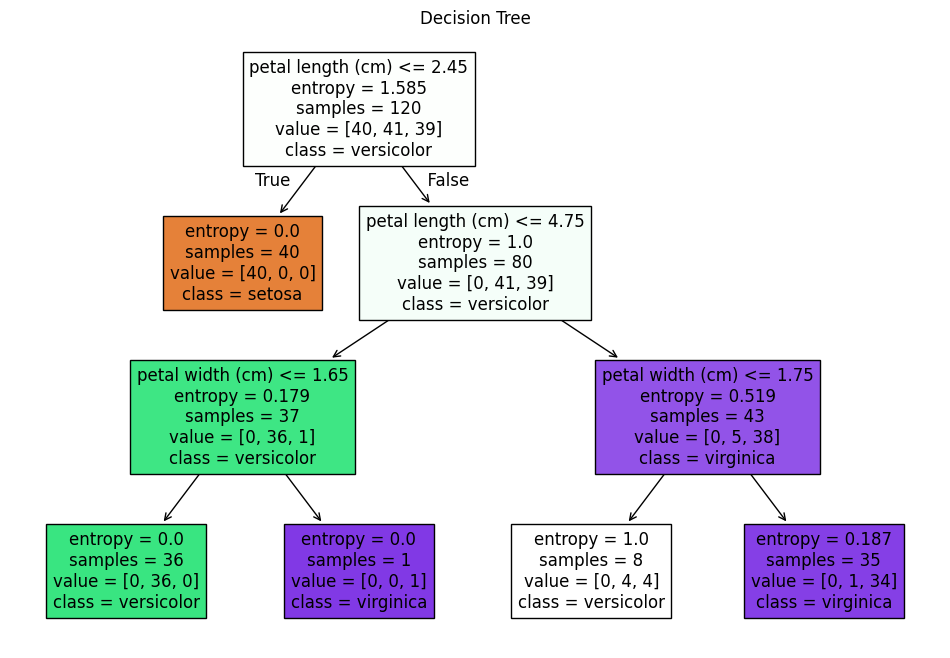

In [11]:
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title('Decision Tree')
plt.show()

## A4. Random Forest (Breast Cancer dataset)

In [12]:
data = load_breast_cancer()
X, y = data.data, data.target

In [13]:
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [14]:
df['target'] = data.target
X = df.loc[:, df.columns != 'target']
y = df.loc[:, 'target'].values

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [17]:
rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_pred = rf_classifier.predict(X_test)

In [19]:
# Evaluate performance  (FIX: results are now printed)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(report)

Accuracy: 0.9649
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



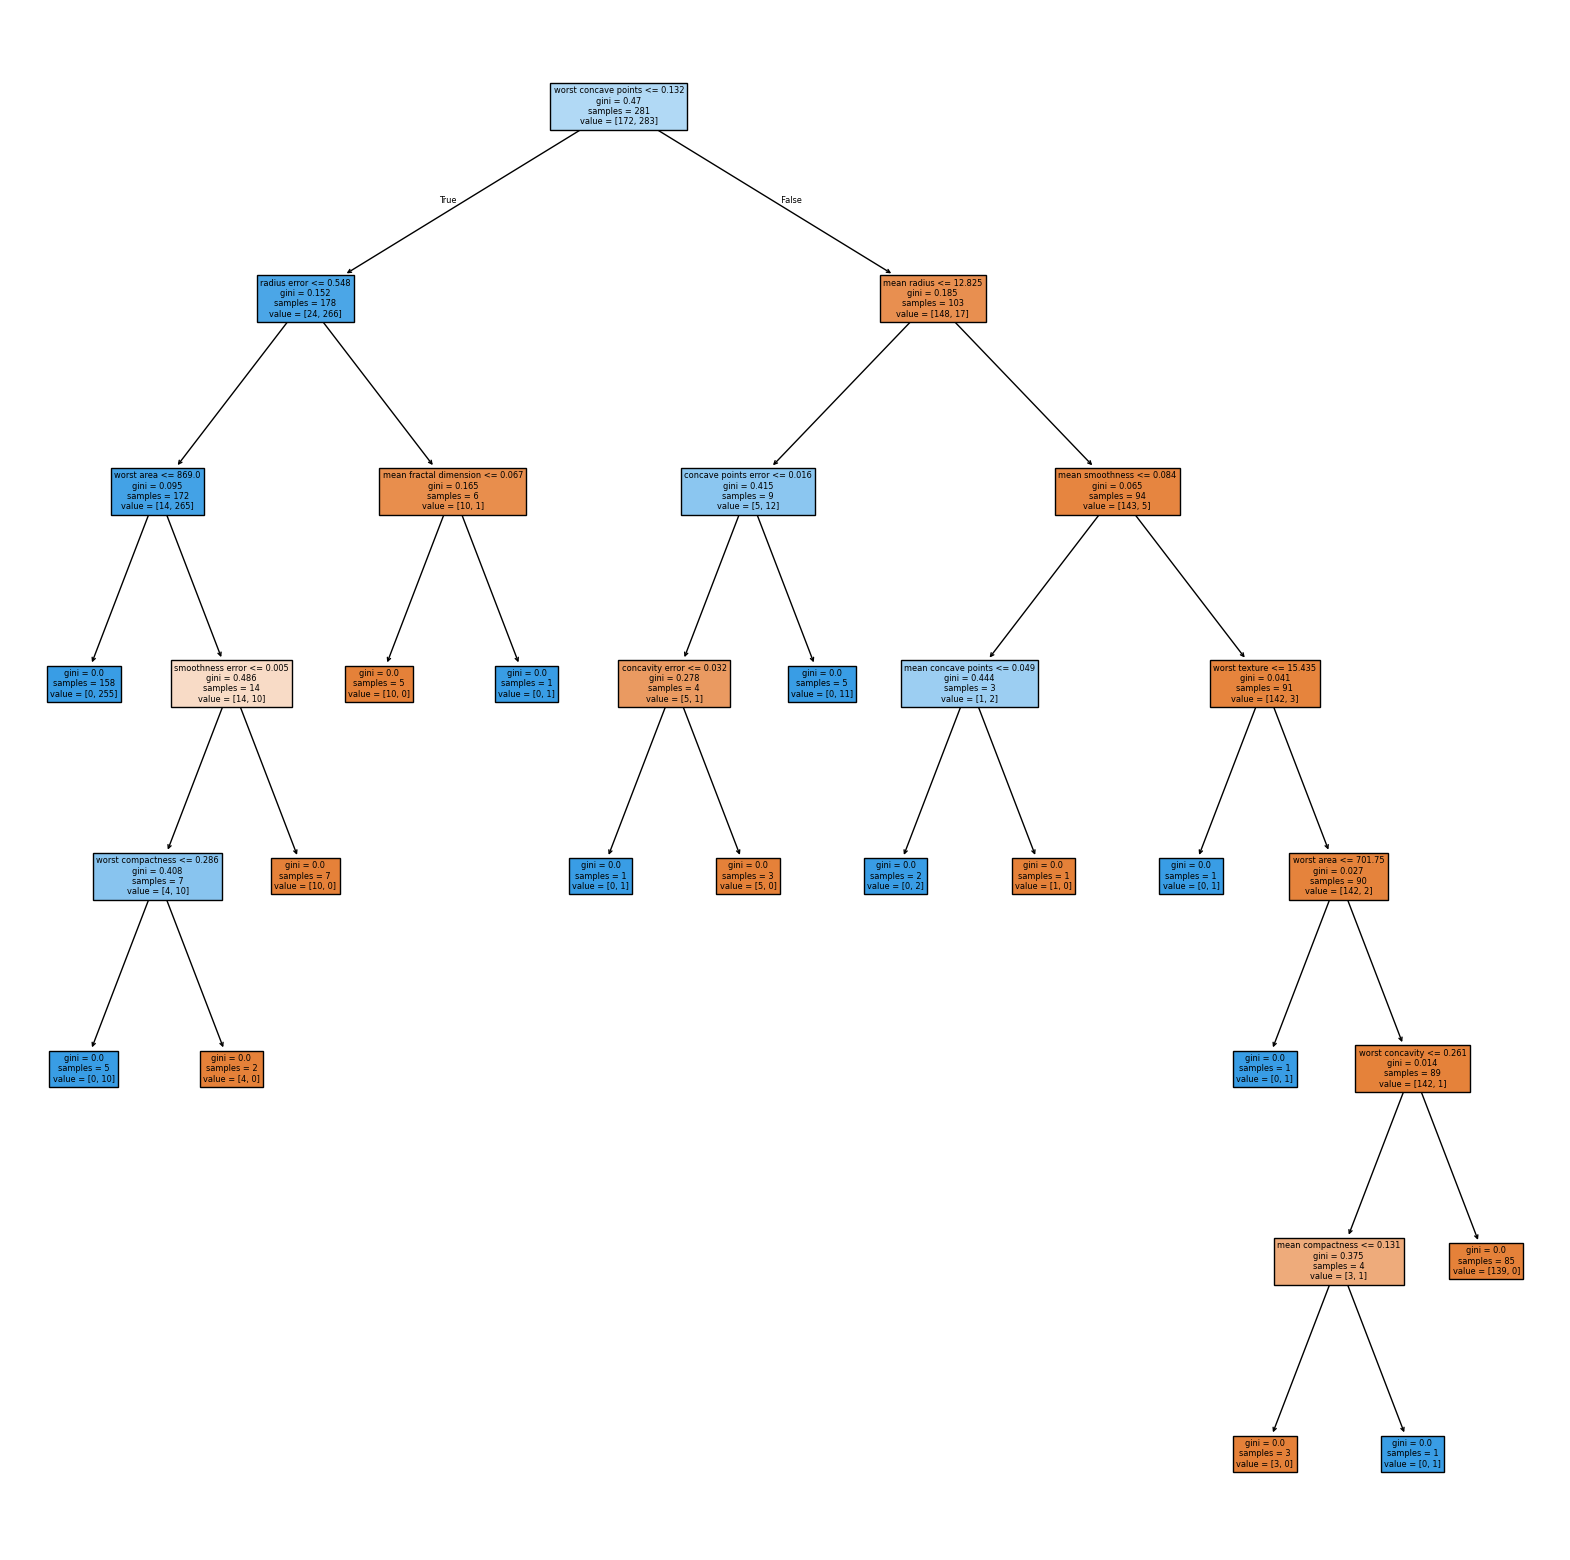

In [20]:
# First tree of the forest (works now that `tree` is no longer overwritten)
plt.figure(figsize=(20, 20))
_ = tree.plot_tree(rf_classifier.estimators_[0], feature_names=X.columns, filled=True)
plt.show()

# PART B — Classify Mushroom Using Decision Tree and Random Forest

**Dataset:** [UCI Mushroom (id 73)](https://archive.ics.uci.edu/dataset/73/mushroom): 8,124 mushrooms, 22 **categorical** features, label `class` = `e` (edible) or `p` (poisonous).

In [21]:
import time
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
sns.set_style('whitegrid')

## B1. Load the dataset

Three sources are tried in order, so the cell works in Colab or locally: the `ucimlrepo` package, the raw UCI file, then a GitHub mirror of the same data. All three are converted to the same format (UCI column names, `'?'` for missing).

In [22]:
UCI_COLS = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
            'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
            'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
            'stalk-surface-below-ring', 'stalk-color-above-ring',
            'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
            'ring-type', 'spore-print-color', 'population', 'habitat']

def load_mushroom():
    # 1) ucimlrepo
    try:
        try:
            from ucimlrepo import fetch_ucirepo
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ucimlrepo'], check=True)
            from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=73)
        m = pd.concat([ds.data.targets, ds.data.features], axis=1)
        m.columns = UCI_COLS
        print('Loaded from ucimlrepo')
        return m.fillna('?')
    except Exception as e:
        print('ucimlrepo failed:', type(e).__name__)
    # 2) raw UCI file
    try:
        url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
        m = pd.read_csv(url, header=None, names=UCI_COLS)
        print('Loaded from UCI archive')
        return m
    except Exception as e:
        print('UCI archive failed:', type(e).__name__)
    # 3) GitHub mirror (same 8124 rows)
    url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/mushrooms.csv'
    m = pd.read_csv(url)
    m.columns = UCI_COLS
    print('Loaded from GitHub mirror')
    return m

mush = load_mushroom()
print(mush.shape)
mush.head()

ucimlrepo failed: ConnectionError
UCI archive failed: HTTPError
Loaded from GitHub mirror
(8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## B2. Exploratory Data Analysis (EDA)

### B2.1 Structure, types and missing values

In [23]:
mush.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [24]:
# Every column is categorical, so describe() shows count / unique / top / freq
mush.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [25]:
# Missing values are stored as '?' in this dataset
missing = (mush == '?').sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print(f"\n{missing.iloc[0]} of {len(mush)} rows ({missing.iloc[0]/len(mush):.1%}) have a missing 'stalk-root'")
print('Duplicate rows:', mush.duplicated().sum())

Columns with missing values:
stalk-root    2480
dtype: int64

2480 of 8124 rows (30.5%) have a missing 'stalk-root'
Duplicate rows: 0


### B2.2 Class balance

class
e    4208
p    3916
Name: count, dtype: int64
class
e    0.518
p    0.482
Name: count, dtype: float64


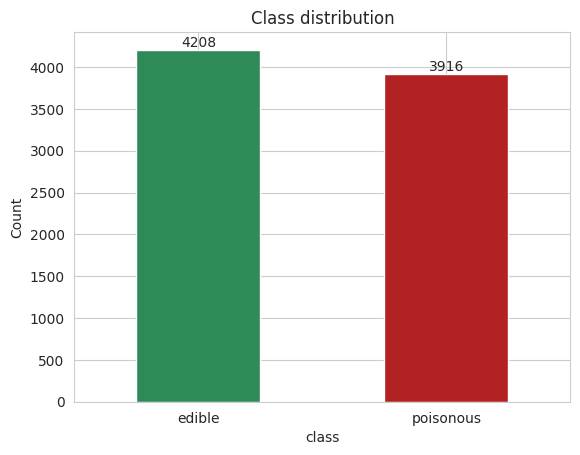

In [26]:
counts = mush['class'].value_counts()
print(counts)
print((counts / len(mush)).round(3))

ax = counts.rename({'e': 'edible', 'p': 'poisonous'}).plot(kind='bar', color=['seagreen', 'firebrick'], rot=0)
ax.set_title('Class distribution'); ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

The classes are nearly balanced (about 52% edible and 48% poisonous). Because of this, **accuracy is a fair metric** here, and no resampling or class weighting is needed.

### B2.3 Number of categories per feature

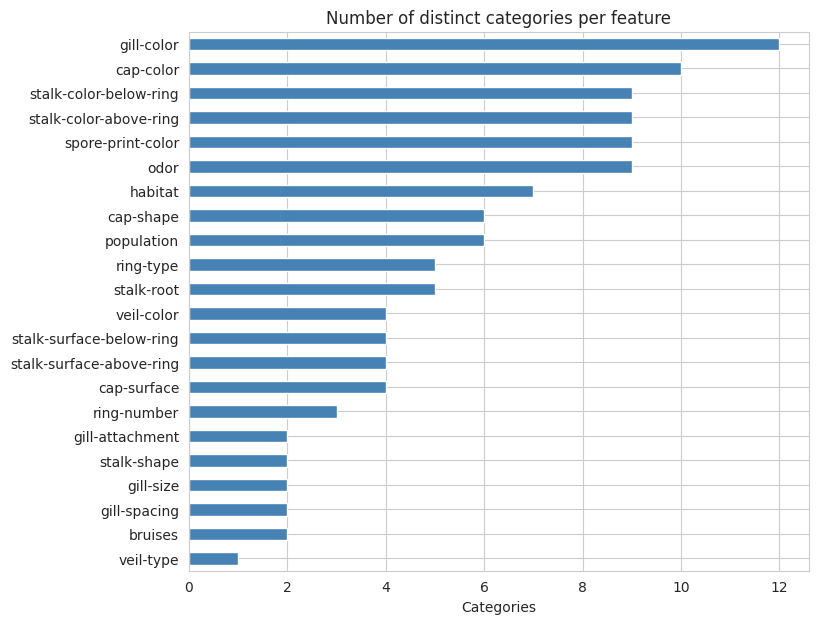

veil-type    1
dtype: int64


In [27]:
n_unique = mush.drop(columns='class').nunique().sort_values()
ax = n_unique.plot(kind='barh', figsize=(8, 7), color='steelblue')
ax.set_title('Number of distinct categories per feature'); ax.set_xlabel('Categories')
plt.show()
print(n_unique[n_unique == 1])

`veil-type` has **only one value** in the whole dataset. A constant feature carries no information (every split on it has zero information gain), so it will be dropped.

### B2.4 How each feature relates to the class

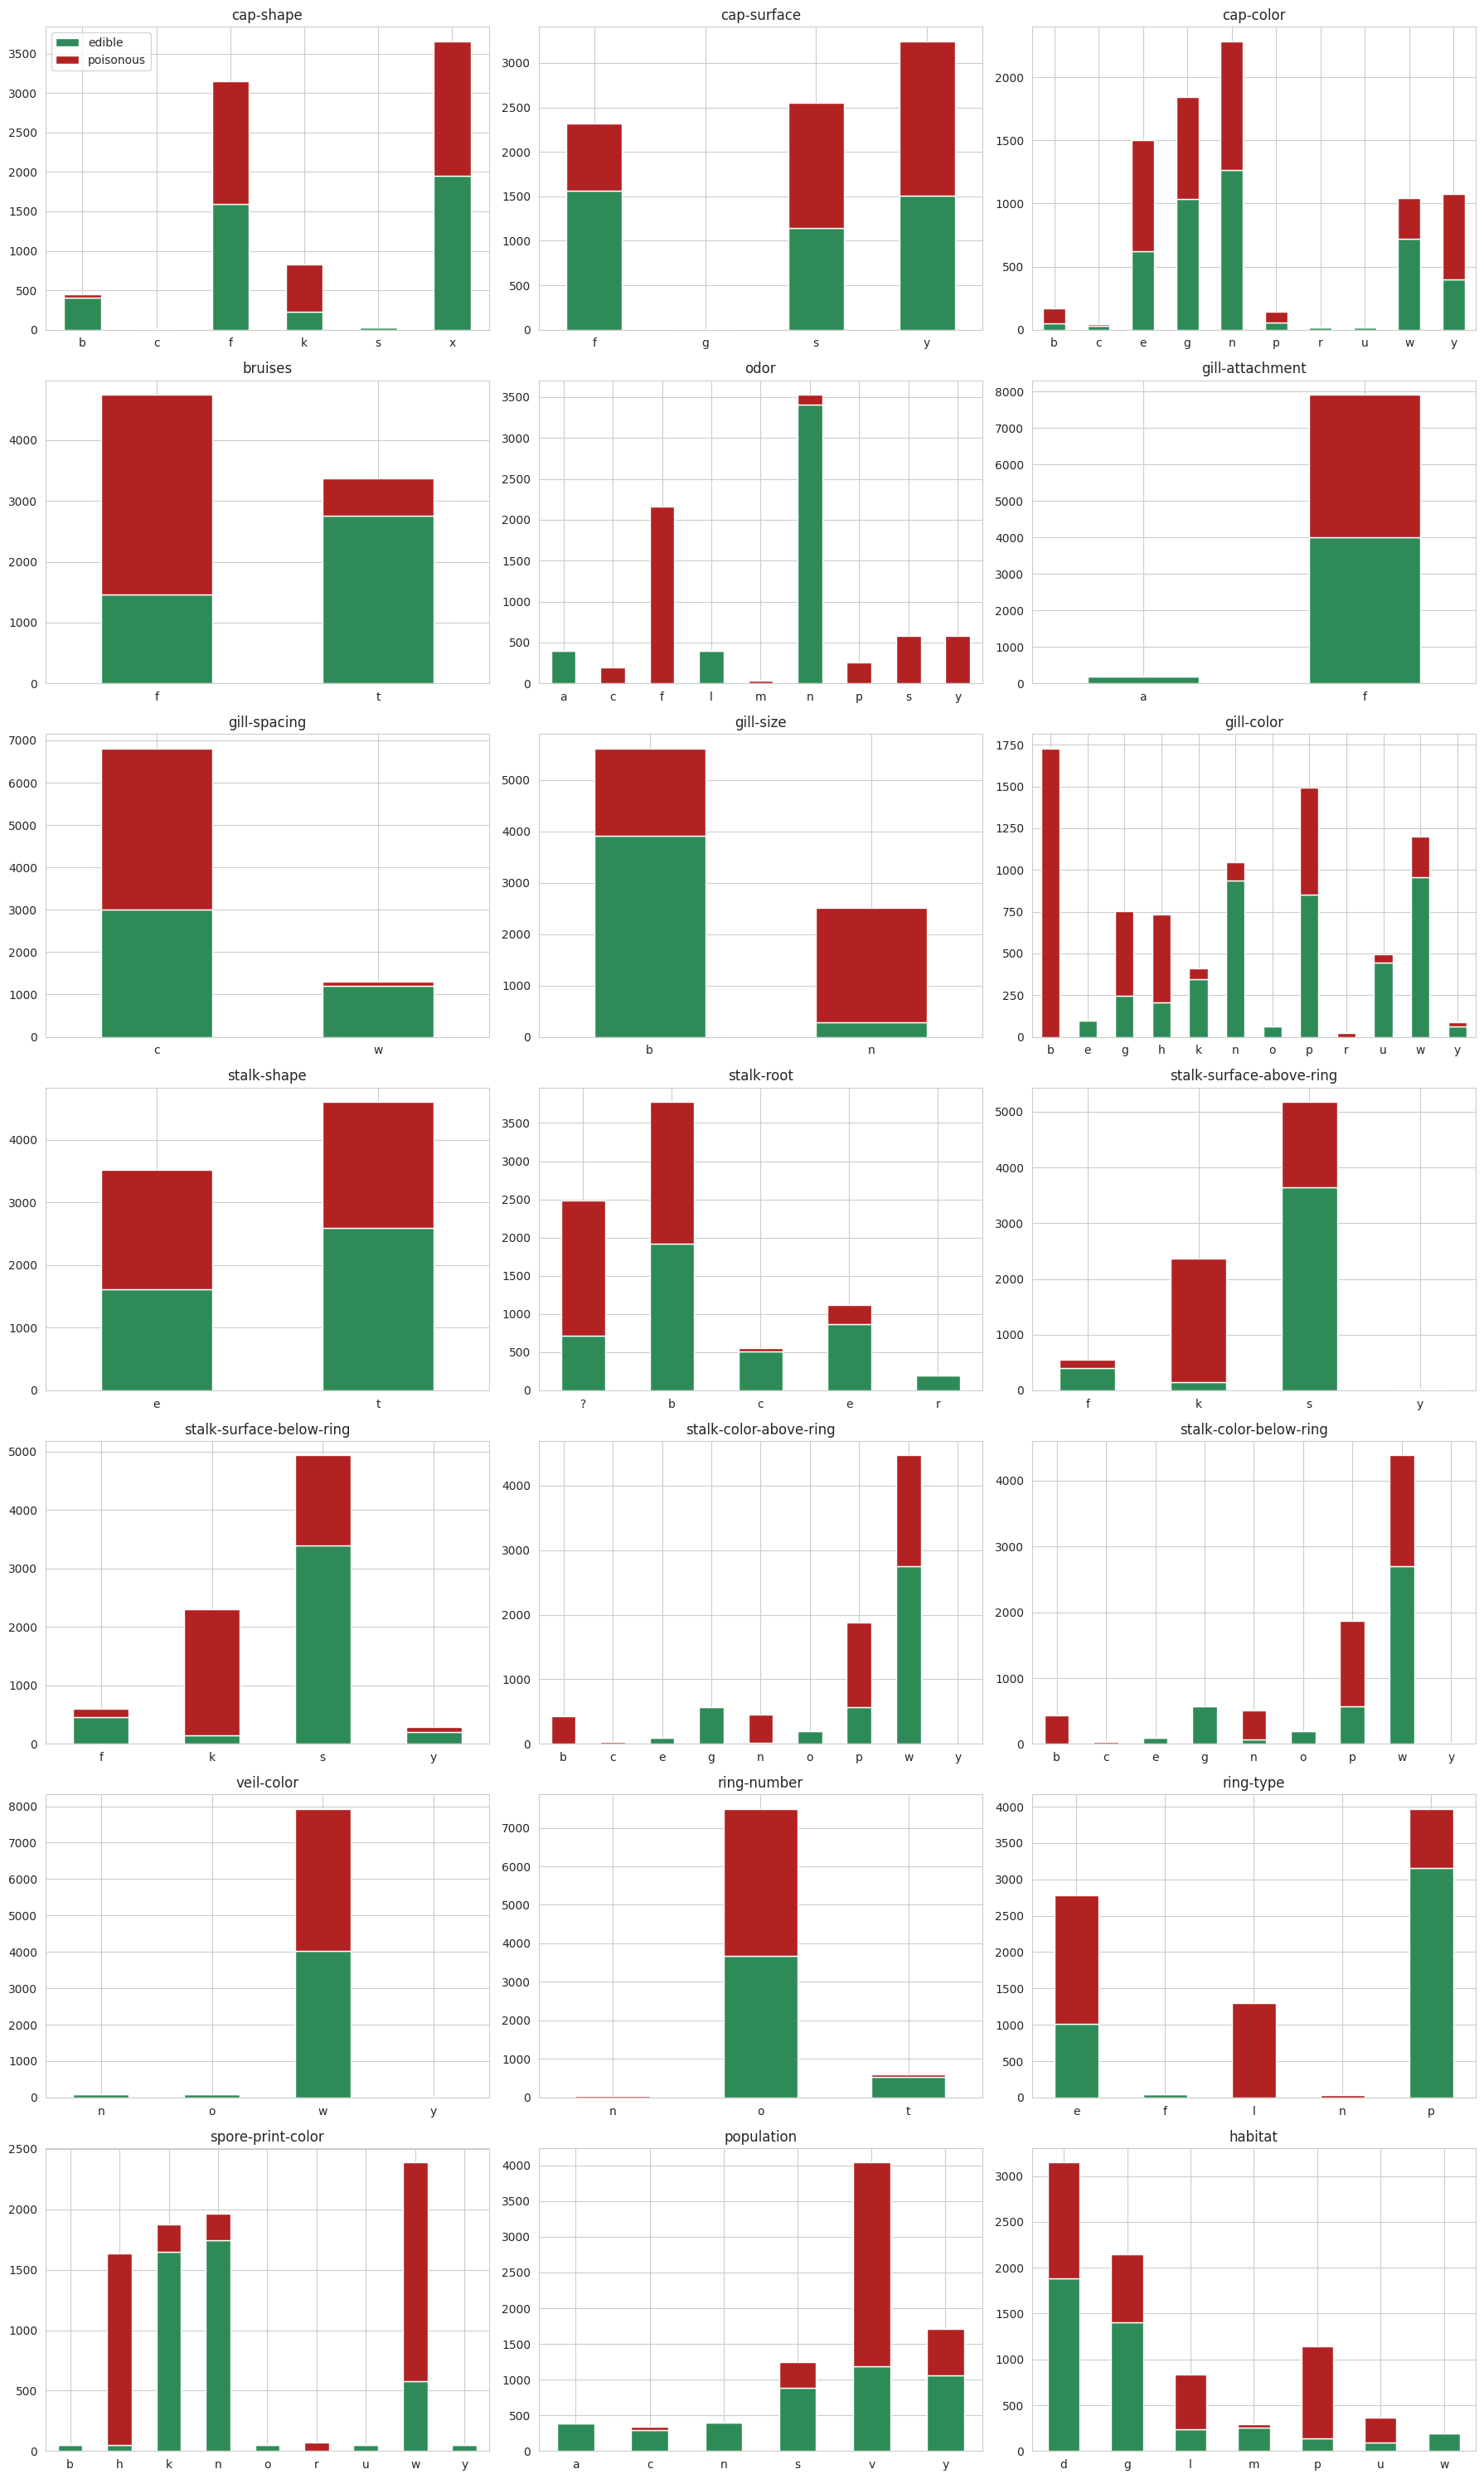

In [28]:
features = [c for c in mush.columns if c not in ('class', 'veil-type')]
fig, axes = plt.subplots(7, 3, figsize=(18, 30))
for ax, col in zip(axes.flat, features):
    ct = pd.crosstab(mush[col], mush['class'])
    ct.plot(kind='bar', stacked=True, ax=ax, color=['seagreen', 'firebrick'], rot=0, legend=False)
    ax.set_title(col); ax.set_xlabel('')
axes.flat[0].legend(['edible', 'poisonous'])
plt.tight_layout()
plt.show()

Many categories are **entirely one colour**, meaning that a single feature value already determines the class. For example, every mushroom with a foul (`f`) odor is poisonous. A decision tree can exploit this directly: a split on such a feature produces pure child nodes, so the information gain is very large.

In [29]:
# Odor vs class — the strongest single predictor
odor_ct = pd.crosstab(mush['odor'], mush['class'], margins=True)
odor_ct

class,e,p,All
odor,,,
a,400,0,400
c,0,192,192
f,0,2160,2160
l,400,0,400
m,0,36,36
n,3408,120,3528
p,0,256,256
s,0,576,576
y,0,576,576


### B2.5 Strength of association: Cramér's V

Cramér's V measures association between two categorical variables on a 0–1 scale (0 = independent, 1 = perfectly associated). It is the categorical counterpart of a correlation coefficient:

$$V = \sqrt{\frac{\chi^2 / n}{\min(r-1,\,k-1)}}$$

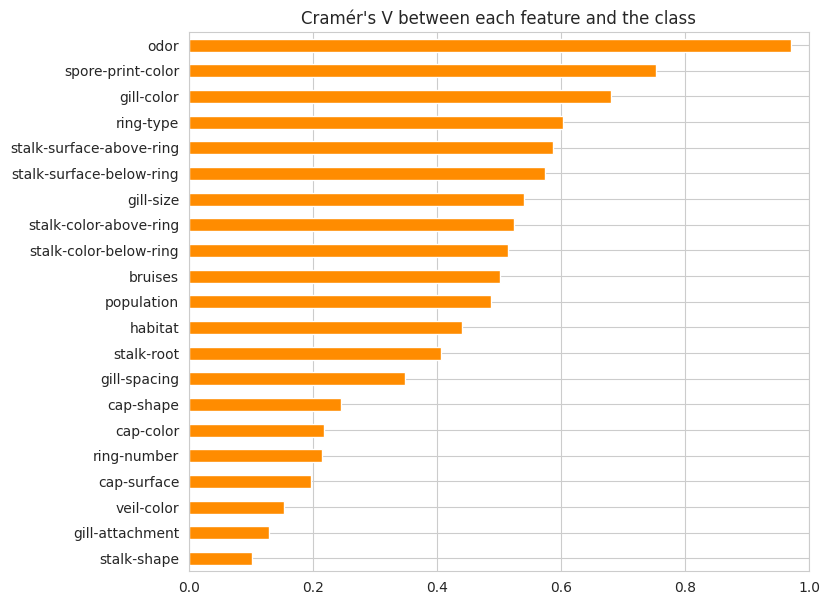

odor                        0.971005
spore-print-color           0.752645
gill-color                  0.680830
ring-type                   0.603271
stalk-surface-above-ring    0.587944
stalk-surface-below-ring    0.574837
dtype: float64

In [30]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

assoc = pd.Series({c: cramers_v(mush[c], mush['class']) for c in features}).sort_values()
ax = assoc.plot(kind='barh', figsize=(8, 7), color='darkorange')
ax.set_title("Cramér's V between each feature and the class"); ax.set_xlim(0, 1)
plt.show()
assoc.sort_values(ascending=False).head(6)

**EDA summary**

- The data has 8,124 rows and 22 categorical features. There are no numeric features, so the features must be **encoded** before scikit-learn can use them.
- `stalk-root` is missing in about 30% of rows. The missing value is kept as its own category (`'missing'`) instead of dropping rows, because missingness may itself be informative and dropping would lose about 30% of the data.
- `veil-type` is constant, so it is dropped.
- `odor` alone is very highly associated with the class (V ≈ 0.97), and several others (`spore-print-color`, `gill-color`, `ring-type`) are strong too. **We should therefore expect tree-based models to reach close to 100% accuracy**, because the classes are almost perfectly separable with a few rules.

## B3. Preprocessing

**One-hot encoding** is used instead of label encoding. Label encoding would map e.g. odor `a, c, f, …` to `0, 1, 2, …`, which invents an order that doesn't exist. A tree splitting on `odor <= 1.5` would then group categories arbitrarily. One-hot encoding gives each category its own 0/1 column, so every split is a clean "is odor = foul?" question.

In [31]:
data_m = mush.drop(columns='veil-type').replace('?', 'missing')

y_m = (data_m['class'] == 'p').astype(int)          # 1 = poisonous, 0 = edible
X_m = pd.get_dummies(data_m.drop(columns='class'), dtype=int)
print('Encoded feature matrix:', X_m.shape)

# Stratified 80/20 split keeps the edible/poisonous ratio the same in train and test
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)
print('Train:', Xm_train.shape, ' Test:', Xm_test.shape)

Encoded feature matrix: (8124, 116)
Train: (6499, 116)  Test: (1625, 116)


## B4. Random Forest accuracy vs `n_estimators` (1, 50, 100, 150, 200, 250)

For each value, we record the **test accuracy**, the **5-fold stratified cross-validation** accuracy (mean ± std, which is more reliable than a single split), and the **training time**.

In [32]:
n_values = [1, 50, 100, 150, 200, 250]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for n in n_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    t0 = time.time()
    rf.fit(Xm_train, ym_train)
    train_time = time.time() - t0
    test_acc = accuracy_score(ym_test, rf.predict(Xm_test))
    cv_scores = cross_val_score(rf, X_m, y_m, cv=cv, scoring='accuracy', n_jobs=-1)
    rows.append({'n_estimators': n, 'test_accuracy': test_acc,
                 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
                 'train_time_s': train_time})

rf_results = pd.DataFrame(rows)
rf_results.style.format({'test_accuracy': '{:.4f}', 'cv_mean': '{:.4f}',
                         'cv_std': '{:.4f}', 'train_time_s': '{:.3f}'})

,n_estimators,test_accuracy,cv_mean,cv_std,train_time_s
0,1,1.0000,1.0000,0.0000,0.023
1,50,1.0000,1.0000,0.0000,0.118
2,100,1.0000,1.0000,0.0000,0.242
3,150,1.0000,1.0000,0.0000,0.467
4,200,1.0000,1.0000,0.0000,0.673
5,250,1.0000,1.0000,0.0000,0.706


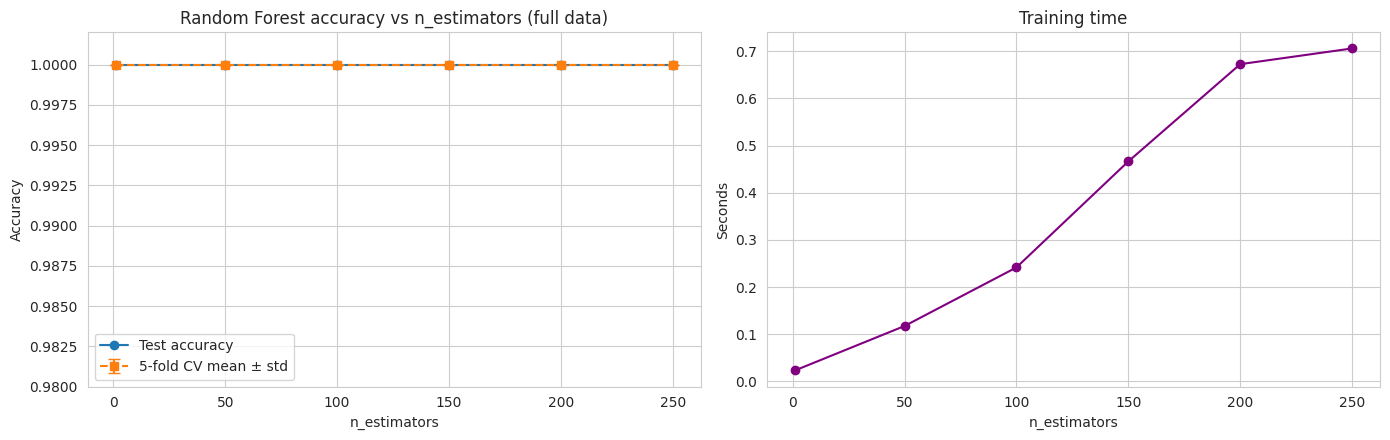

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(rf_results.n_estimators, rf_results.test_accuracy, 'o-', label='Test accuracy')
ax1.errorbar(rf_results.n_estimators, rf_results.cv_mean, yerr=rf_results.cv_std,
             fmt='s--', capsize=4, label='5-fold CV mean ± std')
ax1.set_xlabel('n_estimators'); ax1.set_ylabel('Accuracy'); ax1.set_ylim(0.98, 1.002)
ax1.set_title('Random Forest accuracy vs n_estimators (full data)'); ax1.legend()
ax2.plot(rf_results.n_estimators, rf_results.train_time_s, 'o-', color='purple')
ax2.set_xlabel('n_estimators'); ax2.set_ylabel('Seconds'); ax2.set_title('Training time')
plt.tight_layout(); plt.show()

**Observation.** On the full dataset, accuracy is essentially **100% for every value of `n_estimators`**. As the EDA predicted, the classes are almost perfectly separable, so even one tree finds the rules. Training time, however, grows roughly **linearly** with the number of trees, since each tree is trained independently.

This ceiling hides the effect of `n_estimators`. To see how the number of trees actually matters, the next experiment makes the problem harder.

### B4.1 Stress test: training on only 1% of the data

Each model is trained on only about 81 mushrooms and tested on the remaining 99%. This is repeated over **20 different random splits**, and the mean and standard deviation are reported. With so little data, individual trees overfit their small sample, which is the situation where ensembling helps.

In [34]:
REPEATS, TRAIN_FRAC = 20, 0.01
stress = {n: [] for n in n_values}
stress['Decision Tree'] = []
for seed in range(REPEATS):
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
        X_m, y_m, train_size=TRAIN_FRAC, random_state=seed, stratify=y_m)
    for n in n_values:
        rf = RandomForestClassifier(n_estimators=n, random_state=seed, n_jobs=-1).fit(Xs_tr, ys_tr)
        stress[n].append(rf.score(Xs_te, ys_te))
    stress['Decision Tree'].append(
        DecisionTreeClassifier(random_state=seed).fit(Xs_tr, ys_tr).score(Xs_te, ys_te))

stress_df = pd.DataFrame({k: [np.mean(v), np.std(v)] for k, v in stress.items()},
                         index=['mean_accuracy', 'std']).T
stress_df.index.name = 'model / n_estimators'
stress_df.style.format('{:.4f}')

,mean_accuracy,std
model / n_estimators,,
1,0.9320,0.0359
50,0.9703,0.0118
100,0.9713,0.0119
150,0.9717,0.0107
200,0.9724,0.0112
250,0.9715,0.0110
Decision Tree,0.9643,0.0196


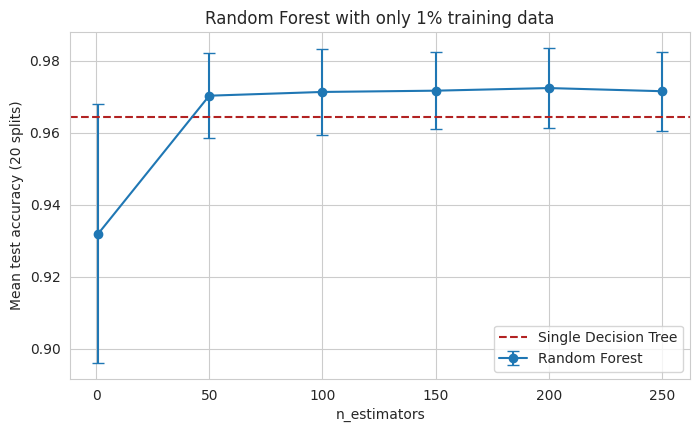

In [35]:
rf_part = stress_df.loc[n_values]
plt.figure(figsize=(8, 4.5))
plt.errorbar(n_values, rf_part['mean_accuracy'], yerr=rf_part['std'], fmt='o-', capsize=4, label='Random Forest')
plt.axhline(stress_df.loc['Decision Tree', 'mean_accuracy'], color='firebrick', ls='--', label='Single Decision Tree')
plt.xlabel('n_estimators'); plt.ylabel(f'Mean test accuracy ({REPEATS} splits)')
plt.title(f'Random Forest with only {TRAIN_FRAC:.0%} training data')
plt.legend(); plt.show()

**Why the curve looks like this**

- **`n_estimators = 1` is the worst and the most unstable.** A 1-tree "forest" is a single tree trained on a **bootstrap sample** (about 63% unique rows) using a **random subset of features** at each split. It sees less data than a normal decision tree and is not allowed to choose the best feature freely, so it is usually *worse* than a plain decision tree.
- **Accuracy jumps sharply from 1 to 50 trees.** Each tree makes different errors because of the different bootstrap samples and feature subsets. Majority voting cancels these errors out. This is **variance reduction**: averaging many partly independent high-variance models gives a lower-variance prediction.
- **After about 50–100 trees the curve flattens.** Once the vote is stable, extra trees mostly repeat what the existing ones already say. The gain stays small while the cost keeps rising linearly. More trees almost never *hurt* accuracy, though, because a random forest does not overfit by adding trees.
- **The standard deviation shrinks as trees are added**, which means the forest is more **consistent** across different training samples.

## B5. Random Forest vs Decision Tree

Both models are evaluated on the same stratified 80/20 split with the same metrics. For this problem the most important error is a **false negative**, i.e. a *poisonous* mushroom predicted as *edible*. That is why **recall for the poisonous class** is reported.

In [36]:
def evaluate(model, name):
    t0 = time.time(); model.fit(Xm_train, ym_train); fit_t = time.time() - t0
    t0 = time.time(); pred = model.predict(Xm_test); pred_t = time.time() - t0
    cv_s = cross_val_score(model, X_m, y_m, cv=cv, scoring='accuracy', n_jobs=-1)
    tn, fp, fn, tp = confusion_matrix(ym_test, pred).ravel()
    return pred, {
        'Model': name,
        'Accuracy': accuracy_score(ym_test, pred),
        'Precision (poisonous)': precision_score(ym_test, pred),
        'Recall (poisonous)': recall_score(ym_test, pred),
        'F1 (poisonous)': f1_score(ym_test, pred),
        'CV mean': cv_s.mean(), 'CV std': cv_s.std(),
        'Poisonous predicted edible (FN)': fn,
        'Fit time (s)': fit_t, 'Predict time (s)': pred_t,
    }

dt_m = DecisionTreeClassifier(criterion='entropy', random_state=42)
rf_m = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

dt_pred, dt_row = evaluate(dt_m, 'Decision Tree')
rf_pred, rf_row = evaluate(rf_m, 'Random Forest (100)')
comparison = pd.DataFrame([dt_row, rf_row]).set_index('Model').T
comparison

Model,Decision Tree,Random Forest (100)
Accuracy,1.000000,1.000000
Precision (poisonous),1.000000,1.000000
Recall (poisonous),1.000000,1.000000
F1 (poisonous),1.000000,1.000000
CV mean,1.000000,1.000000
CV std,0.000000,0.000000
Poisonous predicted edible (FN),0.000000,0.000000
Fit time (s),0.017115,0.242274
Predict time (s),0.001885,0.013650


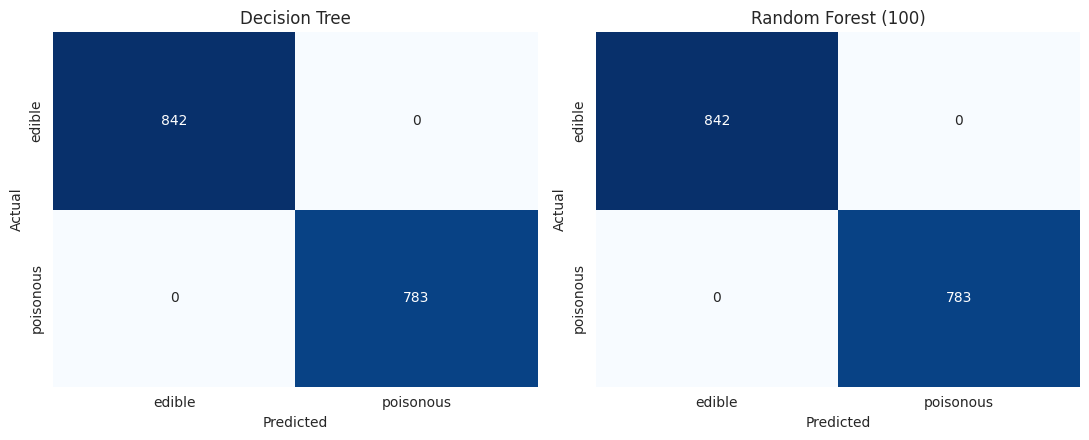

Decision Tree
               precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Random Forest
               precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in [(axes[0], dt_pred, 'Decision Tree'), (axes[1], rf_pred, 'Random Forest (100)')]:
    sns.heatmap(confusion_matrix(ym_test, pred), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['edible', 'poisonous'], yticklabels=['edible', 'poisonous'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

print('Decision Tree\n', classification_report(ym_test, dt_pred, target_names=['edible', 'poisonous']))
print('Random Forest\n', classification_report(ym_test, rf_pred, target_names=['edible', 'poisonous']))

### B5.1 Model complexity and interpretability

Decision Tree : depth = 7, leaves = 13, nodes = 25
Random Forest : 100 trees, 6160 nodes in total


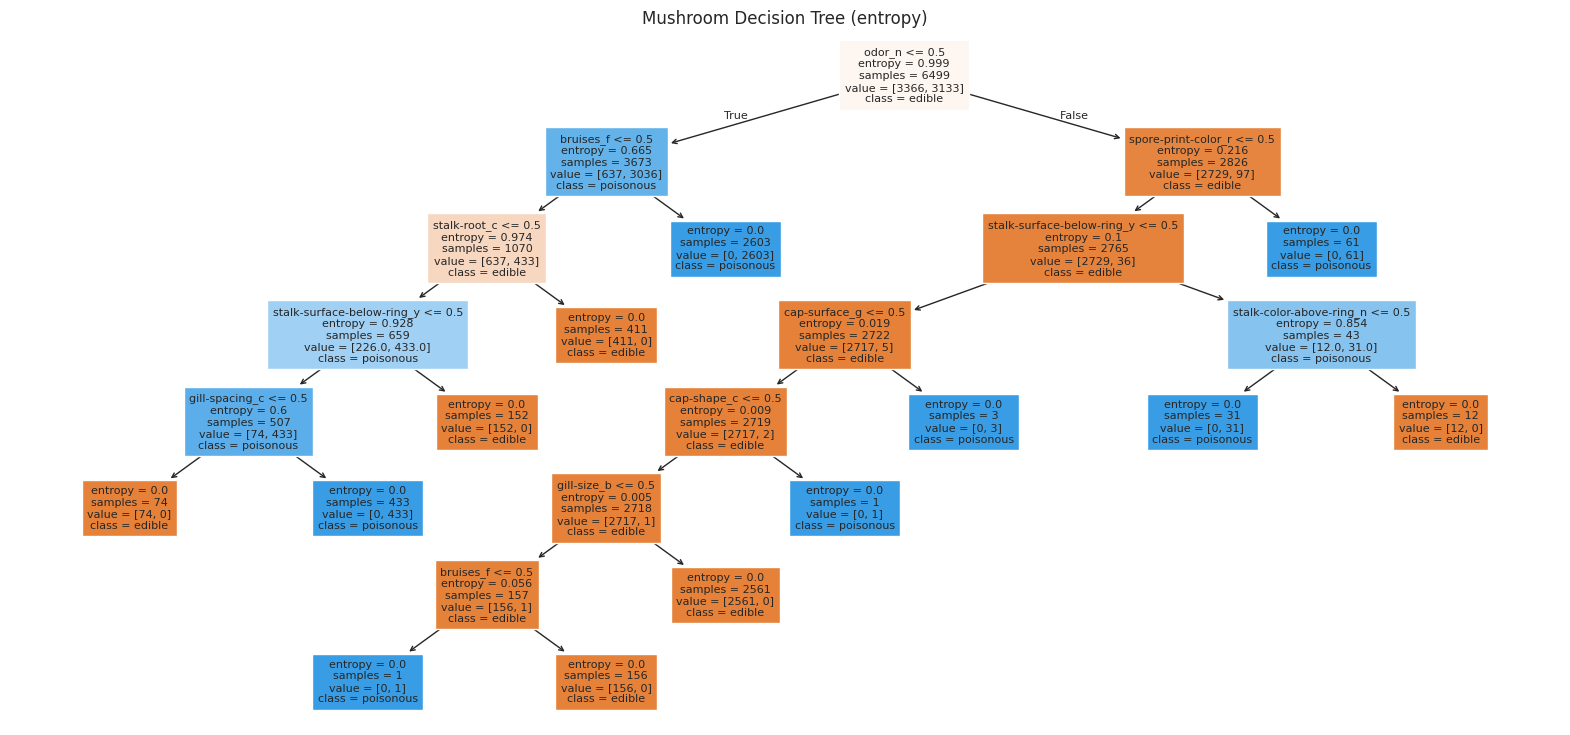

In [38]:
print(f"Decision Tree : depth = {dt_m.get_depth()}, leaves = {dt_m.get_n_leaves()}, nodes = {dt_m.tree_.node_count}")
rf_nodes = sum(est.tree_.node_count for est in rf_m.estimators_)
print(f"Random Forest : {len(rf_m.estimators_)} trees, {rf_nodes} nodes in total")

plt.figure(figsize=(20, 9))
plot_tree(dt_m, feature_names=X_m.columns, class_names=['edible', 'poisonous'],
          filled=True, fontsize=8)
plt.title('Mushroom Decision Tree (entropy)')
plt.show()

The whole decision tree fits in one diagram and can be read as a list of IF–THEN rules (e.g. *IF odor = none AND spore-print-color = green THEN poisonous*). The random forest makes its decision by voting across 100 trees, so it cannot be read as one set of rules. This is the main **interpretability trade-off**.

### B5.2 Feature importance

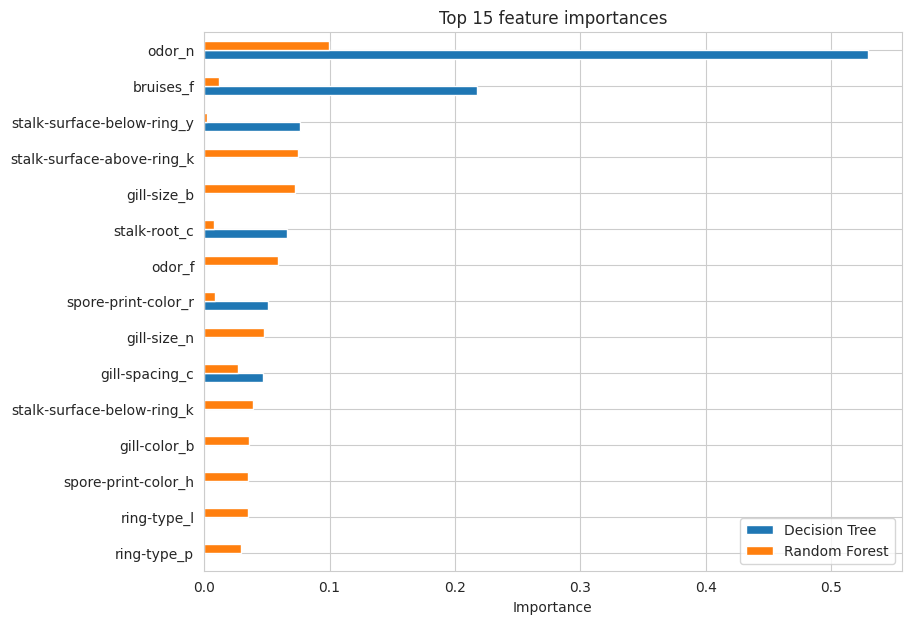

In [39]:
imp = pd.DataFrame({'Decision Tree': dt_m.feature_importances_,
                    'Random Forest': rf_m.feature_importances_}, index=X_m.columns)
top = imp.loc[imp.max(axis=1).sort_values(ascending=False).index[:15]]
top.iloc[::-1].plot(kind='barh', figsize=(9, 7))
plt.title('Top 15 feature importances'); plt.xlabel('Importance')
plt.show()

The decision tree concentrates its importance on **a few features** (mainly odor), because it greedily picks the single best split at the root and everything below depends on it. The random forest **spreads importance** across many correlated features (odor, spore-print-color, gill-size, gill-color, ring-type…). This happens because each split only considers a random subset of features, so many trees are forced to find alternative predictive features when odor is not available. It is also why forests are more robust if one feature is noisy or missing.

### B5.3 Comparison under the harder 1% training setting (from B4.1)

In [40]:
hard = stress_df.loc[['Decision Tree', 100]].rename(index={100: 'Random Forest (100)'})
hard

,mean_accuracy,std
model / n_estimators,,
Decision Tree,0.964342,0.019620
Random Forest (100),0.971317,0.011949


## B6. Conclusion

| Aspect | Decision Tree | Random Forest |
|---|---|---|
| Accuracy (full data) | ≈ 100% | ≈ 100% |
| Accuracy (1% training data) | lower, more variable | higher, more stable |
| Variance / stability | High — sensitive to the exact training sample | Low — averaging reduces variance |
| Interpretability | High — a readable set of rules | Low — a vote of many trees |
| Training / prediction cost | Very small | Grows linearly with `n_estimators` |
| Feature importance | Concentrated on a few features | Spread across correlated features |

1. **The mushroom dataset is almost perfectly separable.** Odor and a few other features determine the class almost exactly, so both models reach about 100% accuracy with sufficient data.
2. **`n_estimators`:** with plenty of data, every value from 1 to 250 reaches the ceiling. With limited data, 1 tree is clearly the worst, accuracy rises sharply up to about 50 trees, and it then plateaus. Beyond about 100 trees, extra trees add training time with little gain.
3. **RF vs DT:** when data is sufficient they tie on accuracy, and the **decision tree is preferable for its simplicity and interpretability**. When data is scarce or noisy, the **random forest is more accurate and more reliable** because bagging and random feature selection reduce variance.
4. For a safety-critical task like this one, the number of **poisonous mushrooms predicted as edible (false negatives)** is the metric that matters most, and it should be checked alongside overall accuracy.